In [1]:
import sys
import os


sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
import warnings

warnings.filterwarnings("ignore")

In [24]:
plt.style.use("seaborn-v0_8")
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

In [13]:
df = pd.read_csv("../Clean_data/clean_data.csv")

In [19]:
cols_name = [
    "hour_value",
    "month",
    "temperature",
    "wind_speed",
    "wind_angle",
    "pressure",
    "humidity",
    "visibility",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "wind_angle_rad",
    "wind_u",
    "wind_v",
]
df[cols_name]

,hour_value,month,temperature,wind_speed,wind_angle,pressure,humidity,visibility,hour_sin,hour_cos,month_sin,month_cos,wind_angle_rad,wind_u,wind_v
0,0,1,19.0,6.0,300.0,1023.0,88.0,6.0,0.000000,1.000000e+00,0.5,0.866025,5.235988,-5.196152,3.000000
1,0,1,19.0,4.0,310.0,1023.0,88.0,6.0,0.000000,1.000000e+00,0.5,0.866025,5.410521,-3.064178,2.571150
2,1,1,19.0,6.0,300.0,1022.0,88.0,6.0,0.258819,9.659258e-01,0.5,0.866025,5.235988,-5.196152,3.000000
3,1,1,19.0,6.0,310.0,1022.0,88.0,6.0,0.258819,9.659258e-01,0.5,0.866025,5.410521,-4.596267,3.856726
4,2,1,19.0,9.0,310.0,1022.0,88.0,6.0,0.500000,8.660254e-01,0.5,0.866025,5.410521,-6.894400,5.785088
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104934,4,5,26.0,4.0,0.0,1007.0,89.0,5.0,0.866025,5.000000e-01,0.5,-0.866025,0.000000,0.000000,4.000000
104935,5,5,26.0,4.0,210.0,1008.0,89.0,5.0,0.965926,2.588190e-01,0.5,-0.866025,3.665191,-2.000000,-3.464102
104936,5,5,26.0,4.0,0.0,1008.0,89.0,5.0,0.965926,2.588190e-01,0.5,-0.866025,0.000000,0.000000,4.000000
104937,6,5,26.0,2.0,0.0,1008.0,89.0,5.0,1.000000,6.123234e-17,0.5,-0.866025,0.000000,0.000000,2.000000


**1. wind_u:** Thành phần gió theo hướng Đông-Tây (East-West)

- Giá trị dương: gió thổi về hướng Đông
- Giá trị âm: gió thổi về hướng Tây
- Công thức: wind_speed * sin(wind_angle_rad)

**2. wind_v:** Thành phần gió theo hướng Bắc-Nam (North-South)

- Giá trị dương: gió thổi về hướng Bắc
- Giá trị âm: gió thổi về hướng Nam
- Công thức: wind_speed * cos(wind_angle_rad)

**3. hour_sin, hour_cos:** Biểu diễn giờ trong ngày (0-23) theo dạng chu kỳ

- Công thức: sin(2π * hour/24) và cos(2π * hour/24)
- Thể hiện tính chu kỳ của thời gian trong ngày

**4. month_sin, month_cos:** Biểu diễn tháng trong năm (1-12) theo dạng chu kỳ

- Công thức: sin(2π * month/12) và cos(2π * month/12)
- Thể hiện tính chu kỳ của tháng trong năm

In [20]:
# Danh sách đặc trưng cho phân cụm
features = [
    # Thông số thời tiết cơ bản
    "temperature",
    "humidity",
    "pressure",
    "visibility_log",
    # Vector gió
    "wind_u",
    "wind_v",
    # Đặc trưng chu kỳ thời gian
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
]

In [21]:

scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(
        df[features]
    ),
    columns=features
)

In [22]:
df_scaled

,temperature,humidity,pressure,visibility_log,wind_u,wind_v,hour_sin,hour_cos,month_sin,month_cos
0,-1.900334,0.781712,2.264454,-0.578728,-1.113804,0.243940,0.015090,1.402199,0.636475,1.232938
1,-1.900334,0.781712,2.264454,-0.578728,-0.770178,0.182916,0.015090,1.402199,0.636475,1.232938
2,-1.900334,0.781712,2.078760,-0.578728,-1.113804,0.243940,0.383489,1.354312,0.636475,1.232938
3,-1.900334,0.781712,2.078760,-0.578728,-1.017116,0.365851,0.383489,1.354312,0.636475,1.232938
4,-1.900334,0.781712,2.078760,-0.578728,-1.387523,0.640253,0.726782,1.213914,0.636475,1.232938
...,...,...,...,...,...,...,...,...,...,...
104934,-0.192644,0.859558,-0.706646,-1.040656,-0.276303,0.386238,1.247777,0.699508,0.636475,-1.234016
104935,-0.192644,0.859558,-0.520953,-1.040656,-0.598657,-0.675889,1.389974,0.360557,0.636475,-1.234016
104936,-0.192644,0.859558,-0.520953,-1.040656,-0.276303,0.386238,1.389974,0.360557,0.636475,-1.234016
104937,-0.192644,0.859558,-0.520953,-1.040656,-0.276303,0.101642,1.438475,-0.003182,0.636475,-1.234016


##### Giảm chiều dữ liệu (NGHIÊN CỨU)

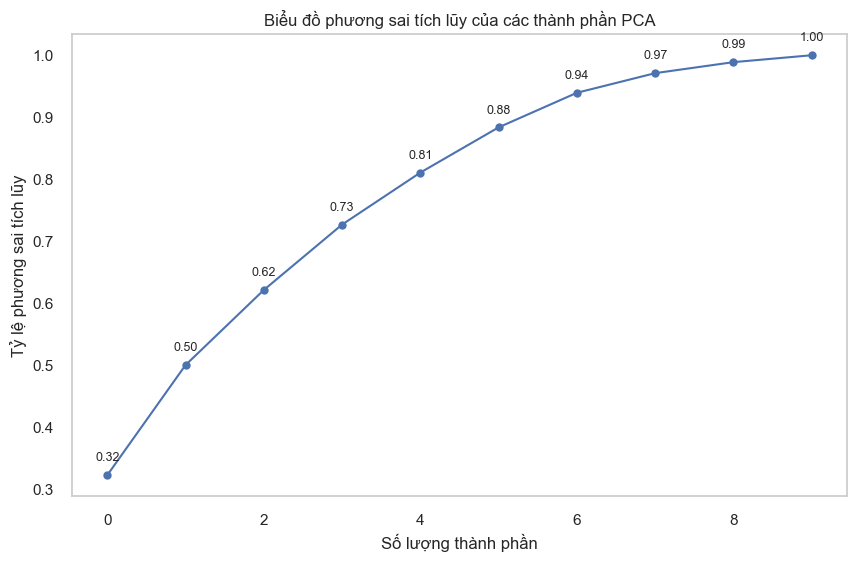

In [25]:
pca_full = PCA()
pca_full.fit(df_scaled)

# Vẽ đồ thị phương sai tích lũy
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker="o")
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
for i, var in enumerate(cumulative_variance):
    plt.annotate(
        f"{var:.2f}",
        (i, var),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9,
        fontweight="normal",
    )
plt.xlabel("Số lượng thành phần")
plt.ylabel("Tỷ lệ phương sai tích lũy")
plt.title("Biểu đồ phương sai tích lũy của các thành phần PCA")
plt.grid()
plt.show()

Sau khi chuẩn hóa dữ liệu, áp dụng PCA (Principal Component Analysis) để giảm chiều dữ liệu từ `10` đặc trưng ban đầu xuống còn `6` thành phần chính, giữ lại  `88.37%` phương sai (thông tin). Trong đó, PC1 và PC2 giữ lần lượt là `32.28%` và `17.76%`, được sử dụng để trực quan hóa dữ liệu và kết quả phân cụm.

=>***Kết luận***:
- Trực quan hóa dữ liệu : 2 Thành phần
- Huấn luyện mô hình :6 Thành phần

In [29]:
pca = PCA(n_components=6)
pca_result = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(
    data=pca_result, columns=["PC1", "PC2", "PC3", "PC4", "PC5", "PC6"]
)

In [30]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)  # Tính phương sai tích lũy
for i, cum_var in enumerate(cumulative_variance):
    print(f"Explained variance by P{i+1}: {explained_variance[i]:.2%}")
print(f"Total explained variance: {sum(explained_variance):.2%}")

Explained variance by P1: 32.28%
Explained variance by P2: 17.76%
Explained variance by P3: 12.11%
Explained variance by P4: 10.55%
Explained variance by P5: 8.39%
Explained variance by P6: 7.29%
Total explained variance: 88.37%


___


### NỘI DUNG 4: MÔ HÌNH HÓA DỮ LIỆU
#### Phần 1. Phân cụm 

Phân cụm (Clustering) là một bài toán thuộc lĩnh vực học không giám sát (unsupervised learning), trong đó mục tiêu là phân chia tập dữ liệu thành các nhóm (cụm) sao cho các điểm dữ liệu trong cùng một cụm có mức độ tương đồng cao, trong khi các cụm khác nhau thì khác biệt rõ rệt. Điểm đặc trưng của bài toán phân cụm là không yêu cầu trước các nhãn (label) cho từng mẫu dữ liệu, mà thuật toán phải tự khám phá ra cấu trúc ẩn bên trong dữ liệu dựa trên đặc trưng đầu vào.

Do không có nhãn để mô hình học từ đó, nên việc phân chia dữ liệu thành tập huấn luyện (train) và kiểm tra (test) như trong học có giám sát không có ý nghĩa rõ ràng. Cụ thể, không có một “giá trị đúng” để mô hình học hoặc kiểm định độ chính xác trên tập kiểm tra. Thay vào đó, mô hình phân cụm thường được huấn luyện và đánh giá trên toàn bộ dữ liệu bằng các tiêu chí nội tại (intrinsic metrics) 

#### A. Mô hình Kmeans

##### 1. Cơ sở lý thuyết:
 K-means là thuật toán phân cụm phân hoạch dựa trên khoảng cách Euclidean, phân chia dữ liệu thành K cụm, mỗi điểm dữ liệu thuộc về cụm có tâm gần nhất. Thuật toán cố gắng tối thiểu hóa tổng bình phương khoảng cách từ mỗi điểm đến tâm cụm gần nhất.

##### 2. Siêu tham số chính:
- n_clusters: Số lượng cụm (K) cần phân chia
- n_init: Số lần chạy thuật toán với các khởi tạo trung tâm cụm khác nhau

##### 3. Lựa chọn siêu tham số cho mô hình
Xác định số lượng cụm tối ưu

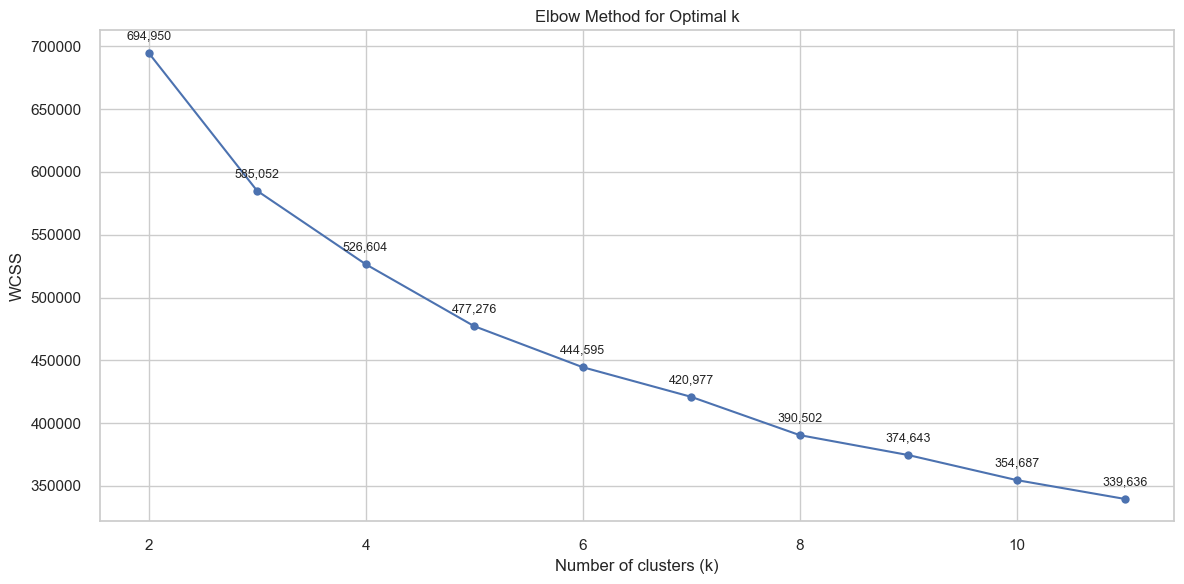

In [31]:
# Phương pháp Elbow để xác định số cụm tối ưu
wcss = []
k_range = range(2, 12, 1)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_pca)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(12, 6))
plt.plot(k_range, wcss, marker="o", linestyle="-")
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")
plt.grid(True)

for i, val in enumerate(wcss):
    plt.annotate(
        f"{int(val):,}",
        (k_range[i], wcss[i]),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9,
    )
plt.tight_layout()
plt.show()

- Chú thích: Giá trị WCSS (Within-Cluster Sum of Squares) - tổng bình phương khoảng cách từ mỗi điểm đến tâm cụm của nó
- Xác định số cụm tối ưu: Phương pháp Elbow, số cụm tối ưu được xác định tại điểm mà đường cong "gãy khúc" rõ rệt - nơi mà việc tăng thêm số cụm không còn cải thiện WCSS đáng kể.


`Nhận xét:`
- Các đoạn từ k=2 đến k=5 dốc, có WCSS giảm mạnh, cho thấy sự phân tách rõ ràng giữa các cụm.
- Tại k=6 đến k=10, độ dốc giảm rõ rệt, cho thấy sự cải thiện không đáng kể trong việc phân tách các cụm.
- Do đó, số lượng cụm tối ưu được chọn là `k=5`, vì đây là điểm mà WCSS giảm mạnh nhất và sau đó bắt đầu ổn định. 

Tham số tối ưu n_clusters= 5 

##### 4. Huấn luyện K-means

In [32]:
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(df_pca)

In [ ]:
import pickle
import joblib
from pathlib import Path

Path("models").mkdir(exist_ok=True)
with open("models/kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)

##### 5. Trực quan hóa kết quả K-means

*Phân phối số lượng mẫu trong từng cụm

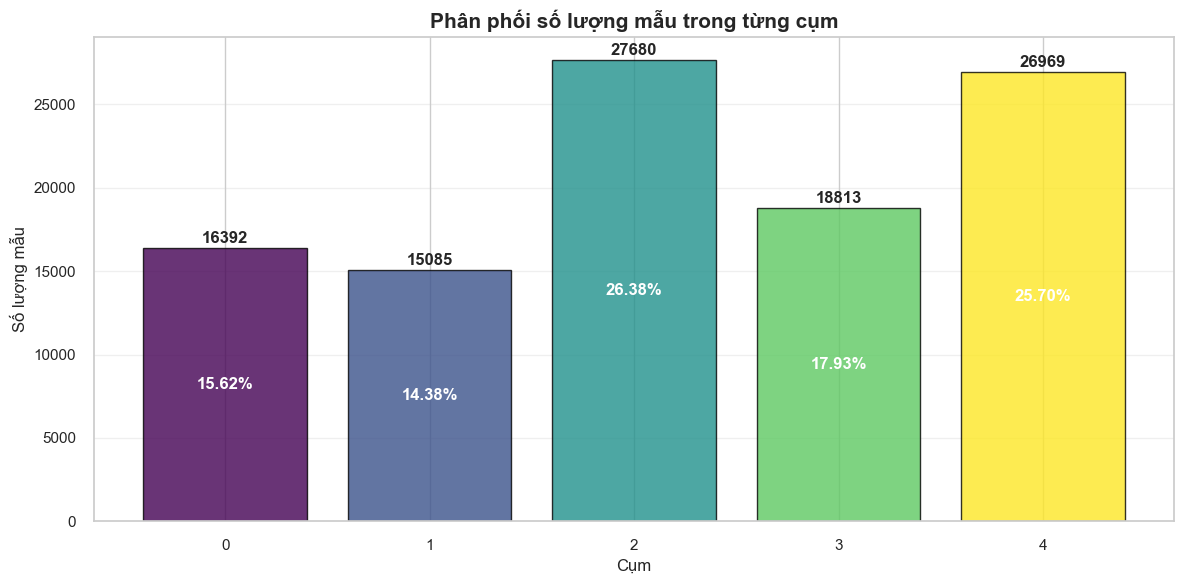

In [54]:
plt.figure(figsize=(12, 6))
cluster_counts = df["cluster"].value_counts().sort_index()

total_samples = cluster_counts.sum()

colors = plt.cm.viridis(np.linspace(0, 1, optimal_k))
bars = plt.bar(
    cluster_counts.index,
    cluster_counts.values,
    color=colors,
    alpha=0.8,
    edgecolor="black",
)

for bar in bars:
    height = bar.get_height()
    percent = 100 * height / total_samples
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 100,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height / 2,
        f"{percent:.2f}%",
        ha="center",
        va="center",
        fontweight="bold",
        color="white",
    )

plt.title("Phân phối số lượng mẫu trong từng cụm", fontsize=15, fontweight="bold")
plt.xlabel("Cụm", fontsize=12,)
plt.ylabel("Số lượng mẫu", fontsize=12)
plt.xticks(range(optimal_k))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Nhận xét:**
- Biểu đồ cho thấy dữ liệu thời tiết có sự phân bố không đồng đều, với một số kiểu thời tiết (cụm 2 và 4) xuất hiện thường xuyên hơn
- Cụm 0 và 1 (ít mẫu hơn) có thể đại diện cho các điều kiện thời tiết hiếm gặp hơn

*Trực quan hóa cụm trên không gian PCA

Text(0, 0.5, 'PC2 ')

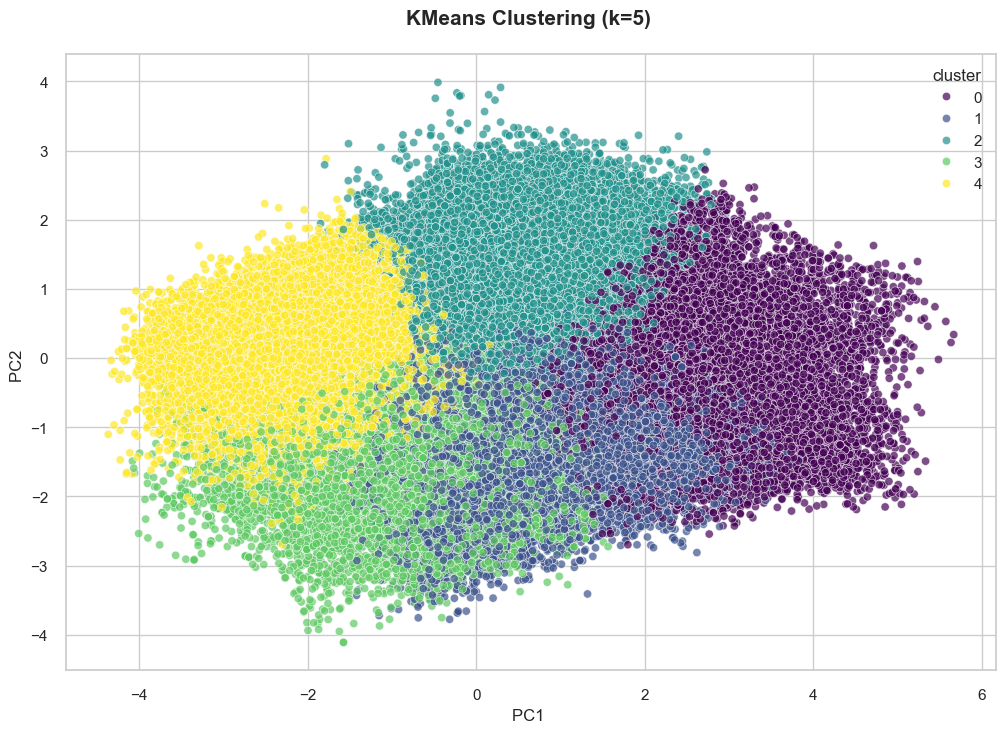

In [35]:
sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="cluster",
    data=pd.concat([df_pca, df[["cluster"]]], axis=1),
    palette="viridis",
    alpha=0.7,
    # s=20,
)

plt.title(
    f"KMeans Clustering (k={optimal_k}) \n",
    fontsize=15,
    fontweight="bold",
)
plt.xlabel("Thành phần chính 1 (PC1)", fontsize=12)
plt.ylabel("Thành phần chính 2 (PC2)", fontsize=12)
explained_variance = pca.explained_variance_ratio_
plt.xlabel(f"PC1 ", fontsize=12)
plt.ylabel(f"PC2 ", fontsize=12)

**Nhận xét:**
- Dữ liệu thành 5 cụm khá rõ ràng trên không gian 2D của hai thành phần chính PC1 và PC2. Các cụm có hình dạng gần như tách biệt, cho thấy thuật toán đã xác định được các nhóm thời tiết có đặc điểm riêng biệt
- Có một số vùng chồng lấn nhỏ giữa các cụm, đặc biệt là giữa cluster 1 và các cluster khác, cho thấy có thể có một số điểm dữ liệu nằm ở ranh giới giữa các kiểu thời tiết.

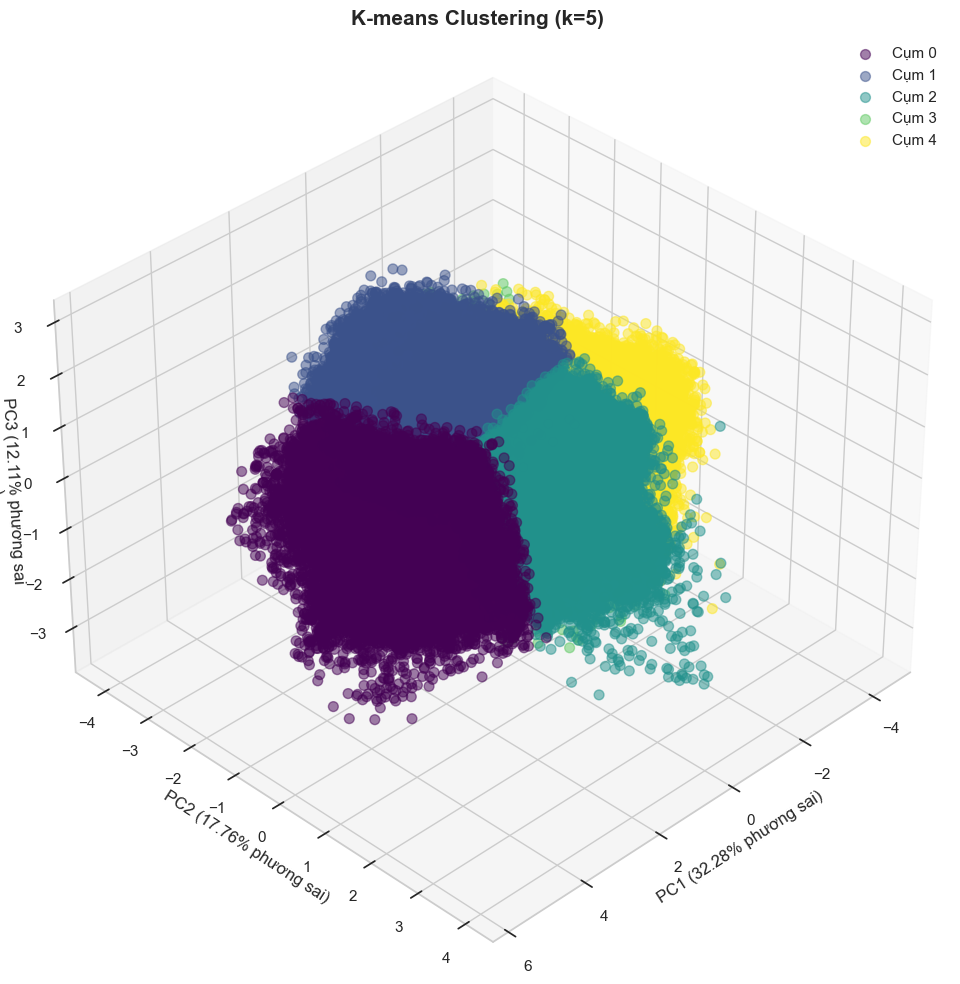

In [38]:
# Biểu đồ 3D cho phân cụm K-means
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")
colors = plt.cm.viridis(np.linspace(0, 1, optimal_k))
for cluster_idx in range(optimal_k):
    cluster_data = pd.concat([df_pca, df[["cluster"]]], axis=1)[
        df["cluster"] == cluster_idx
    ]

    ax.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        cluster_data["PC3"],
        c=[colors[cluster_idx]],
        s=50,
        alpha=0.5,
        label=f"Cụm {cluster_idx}",
    )
ax.set_title(f"K-means Clustering (k={optimal_k}) ", fontsize=15, fontweight="bold")
ax.set_xlabel(f"PC1 ({explained_variance[0]:.2%} phương sai)", fontsize=12)
ax.set_ylabel(f"PC2 ({explained_variance[1]:.2%} phương sai)", fontsize=12)
ax.set_zlabel(f"PC3 ({explained_variance[2]:.2%} phương sai\n)", fontsize=12)
ax.legend()
ax.view_init(elev=35, azim=45)
plt.tight_layout()
plt.show()

##### 6. Phân tích đặc điểm cụm và áp dụng domain knowledge

Phân bố cụm theo tháng

<Figure size 1400x800 with 0 Axes>

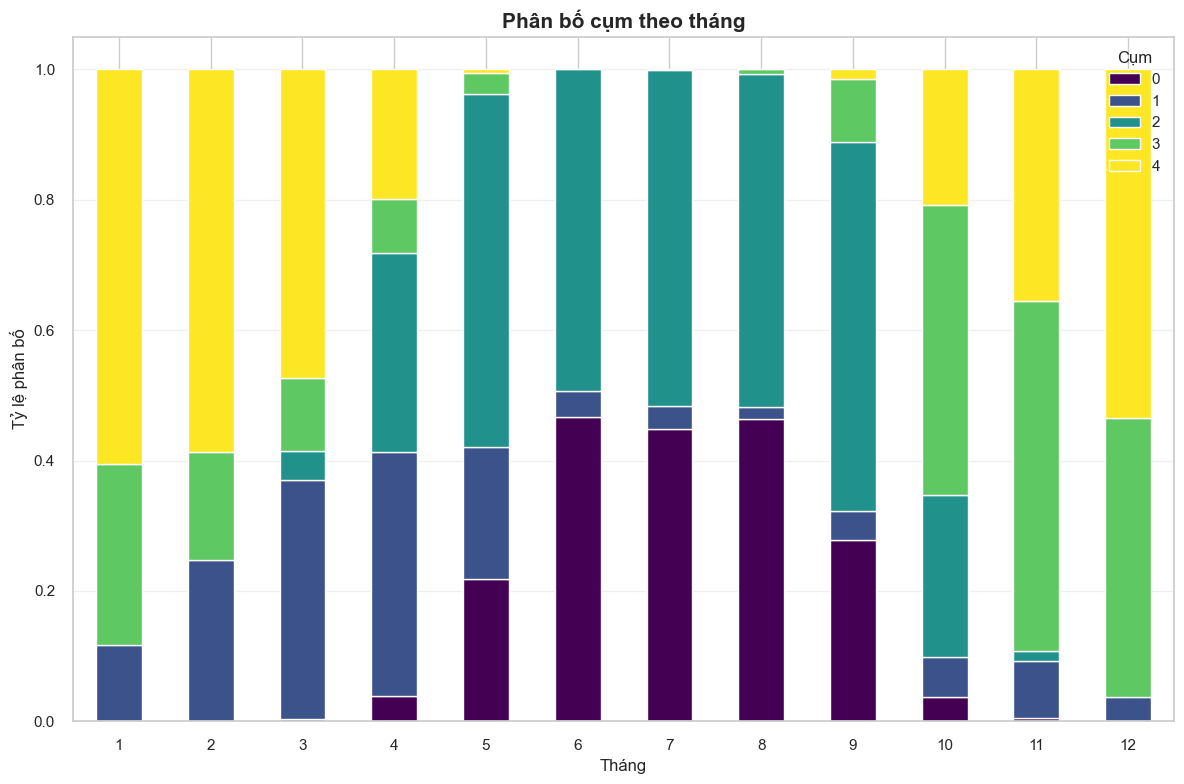

In [39]:
# Phân tích phân bố cụm theo tháng
plt.figure(figsize=(14, 8))

monthly_cluster = pd.crosstab(df["month"], df["cluster"])

monthly_cluster_pct = monthly_cluster.div(monthly_cluster.sum(axis=1), axis=0)
monthly_cluster_pct.plot(kind="bar", stacked=True, colormap="viridis")

plt.title("Phân bố cụm theo tháng", fontsize=15, fontweight="bold")
plt.xlabel("Tháng", fontsize=12)
plt.ylabel("Tỷ lệ phân bố", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Cụm")
plt.tight_layout()
plt.show()

**Kiến thức:**
- Đà Nẵng thuộc vùng Duyên hải Nam Trung Bộ
- Khí hậu Đà Nẵng có hai mùa rõ rệt: mùa khô và mùa mưa
    - Mùa khô Đà Nẵng thường bắt đầu từ tháng 1 đến hết tháng 7;
    - Mùa mưa Đà Nẵng kéo dài từ tháng 8 đến tháng 12, có thể kéo dài đến tháng 1 năm sau.
- Các tháng 1, 2, 3, 4, 5, 6 thường có thời tiết nắng nóng, ít mưa
- Các tháng 7, 8, 9, 10, 11, 12 thường có mưa nhiều hơn, đặc biệt là tháng 10 và tháng 11
- Các tháng 9, 10, 11 thường có bão và áp thấp nhiệt đới

**Nhận xét:**
  1. Tính mùa vụ rõ rệt trong các cụm thời tiết:
      - Các cụm 0,1,2 chủ yếu tập trung từ tháng 2 đến tháng 9. Đây có thể là các cụm thời tiết đặc trưng cho mùa khô
      - Các cụm 3,4 chủ yếu tập trung từ tháng 10 đến tháng 1 năm sau. Đây có thể là các cụm thời tiết đặc trưng cho mùa mưa
  2. Tính ổn định theo mùa:
      - Tháng 6-8 có cấu trúc phân bố cụm rất giống nhau, với cụm 0 và cụm 2 chiếm ưu thế , và tỉ lệ gần như bằng nhau.
      - Tương tự , sự phân bố các cụm trên tháng 1-3 và tháng 10-12 khá giống nhau.
  3. Đặc thù của tháng:
      - Tháng 5 đến tháng 9 hầu như không có sự xuất hiện của cụm 4, đối lập với tháng 11 đến tháng 3 xuất hiện chủ yếu.

In [42]:
df

,year,month,day,hour_value,minute,weather,temperature,wind_speed,wind_angle,humidity,...,minute_sin,minute_cos,month_sin,month_cos,day_sin,day_cos,wind_angle_rad,wind_u,wind_v,cluster
0,2019,1,1,0,0,Clear,19.0,6.0,300.0,88.0,...,0.000000e+00,1.0,0.5,0.866025,0.201299,0.979530,5.235988,-5.196152,3.000000,4
1,2019,1,1,0,30,Clear,19.0,4.0,310.0,88.0,...,5.665539e-16,-1.0,0.5,0.866025,0.201299,0.979530,5.410521,-3.064178,2.571150,4
2,2019,1,1,1,0,Clear,19.0,6.0,300.0,88.0,...,0.000000e+00,1.0,0.5,0.866025,0.201299,0.979530,5.235988,-5.196152,3.000000,4
3,2019,1,1,1,30,Clear,19.0,6.0,310.0,88.0,...,5.665539e-16,-1.0,0.5,0.866025,0.201299,0.979530,5.410521,-4.596267,3.856726,4
4,2019,1,1,2,0,Clear,19.0,9.0,310.0,88.0,...,0.000000e+00,1.0,0.5,0.866025,0.201299,0.979530,5.410521,-6.894400,5.785088,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104934,2025,5,21,4,30,Clear,26.0,4.0,0.0,89.0,...,5.665539e-16,-1.0,0.5,-0.866025,-0.897805,-0.440394,0.000000,0.000000,4.000000,2
104935,2025,5,21,5,0,Clear,26.0,4.0,210.0,89.0,...,0.000000e+00,1.0,0.5,-0.866025,-0.897805,-0.440394,3.665191,-2.000000,-3.464102,2
104936,2025,5,21,5,30,Clear,26.0,4.0,0.0,89.0,...,5.665539e-16,-1.0,0.5,-0.866025,-0.897805,-0.440394,0.000000,0.000000,4.000000,2
104937,2025,5,21,6,0,Clear,26.0,2.0,0.0,89.0,...,0.000000e+00,1.0,0.5,-0.866025,-0.897805,-0.440394,0.000000,0.000000,2.000000,2


In [43]:
cluster_summary = (
    df.groupby("cluster")
    .agg(
        {
            "temperature": "mean",
            "humidity": "mean",
            "wind_speed": "mean",
            "pressure": "mean",
            "visibility_log": "mean",
            "wind_u": "mean",
            "wind_v": "mean",
            "hour_sin": "mean",
            "hour_cos": "mean",
            "month_sin": "mean",
            "month_cos": "mean",
        }
    )
    .round(2)
)
weather_distribution = pd.crosstab(
    df["cluster"], df["weather"], normalize="index"
).round(2)
cluster_summary = pd.concat([cluster_summary, weather_distribution], axis=1)
print("Bảng tổng hợp đặc điểm của từng cụm:")
display(cluster_summary)

Bảng tổng hợp đặc điểm của từng cụm:


,temperature,humidity,wind_speed,pressure,visibility_log,wind_u,wind_v,hour_sin,hour_cos,month_sin,month_cos,Clear,Cloudy,Foggy,Rainy,Stormy
cluster,,,,,,,,,,,,,,,,
0,33.10,59.00,9.69,1005.41,2.41,2.50,0.98,-0.03,-0.63,-0.39,-0.65,0.81,0.18,0.00,0.01,0.01
1,28.57,71.49,12.05,1010.77,2.10,10.57,-3.17,-0.41,-0.57,0.58,-0.05,0.76,0.22,0.00,0.01,0.01
2,27.22,83.65,4.86,1006.88,2.21,-1.42,-2.09,0.10,0.55,-0.24,-0.52,0.86,0.05,0.01,0.07,0.02
3,25.20,77.46,11.88,1014.63,2.03,1.96,9.99,-0.32,-0.41,-0.08,0.61,0.49,0.30,0.00,0.20,0.01
4,22.62,87.61,4.58,1015.47,2.00,-0.67,1.36,0.33,0.43,0.40,0.54,0.67,0.09,0.07,0.17,0.00


*Biểu đồ phân phối các đặc trưng theo từng cụm

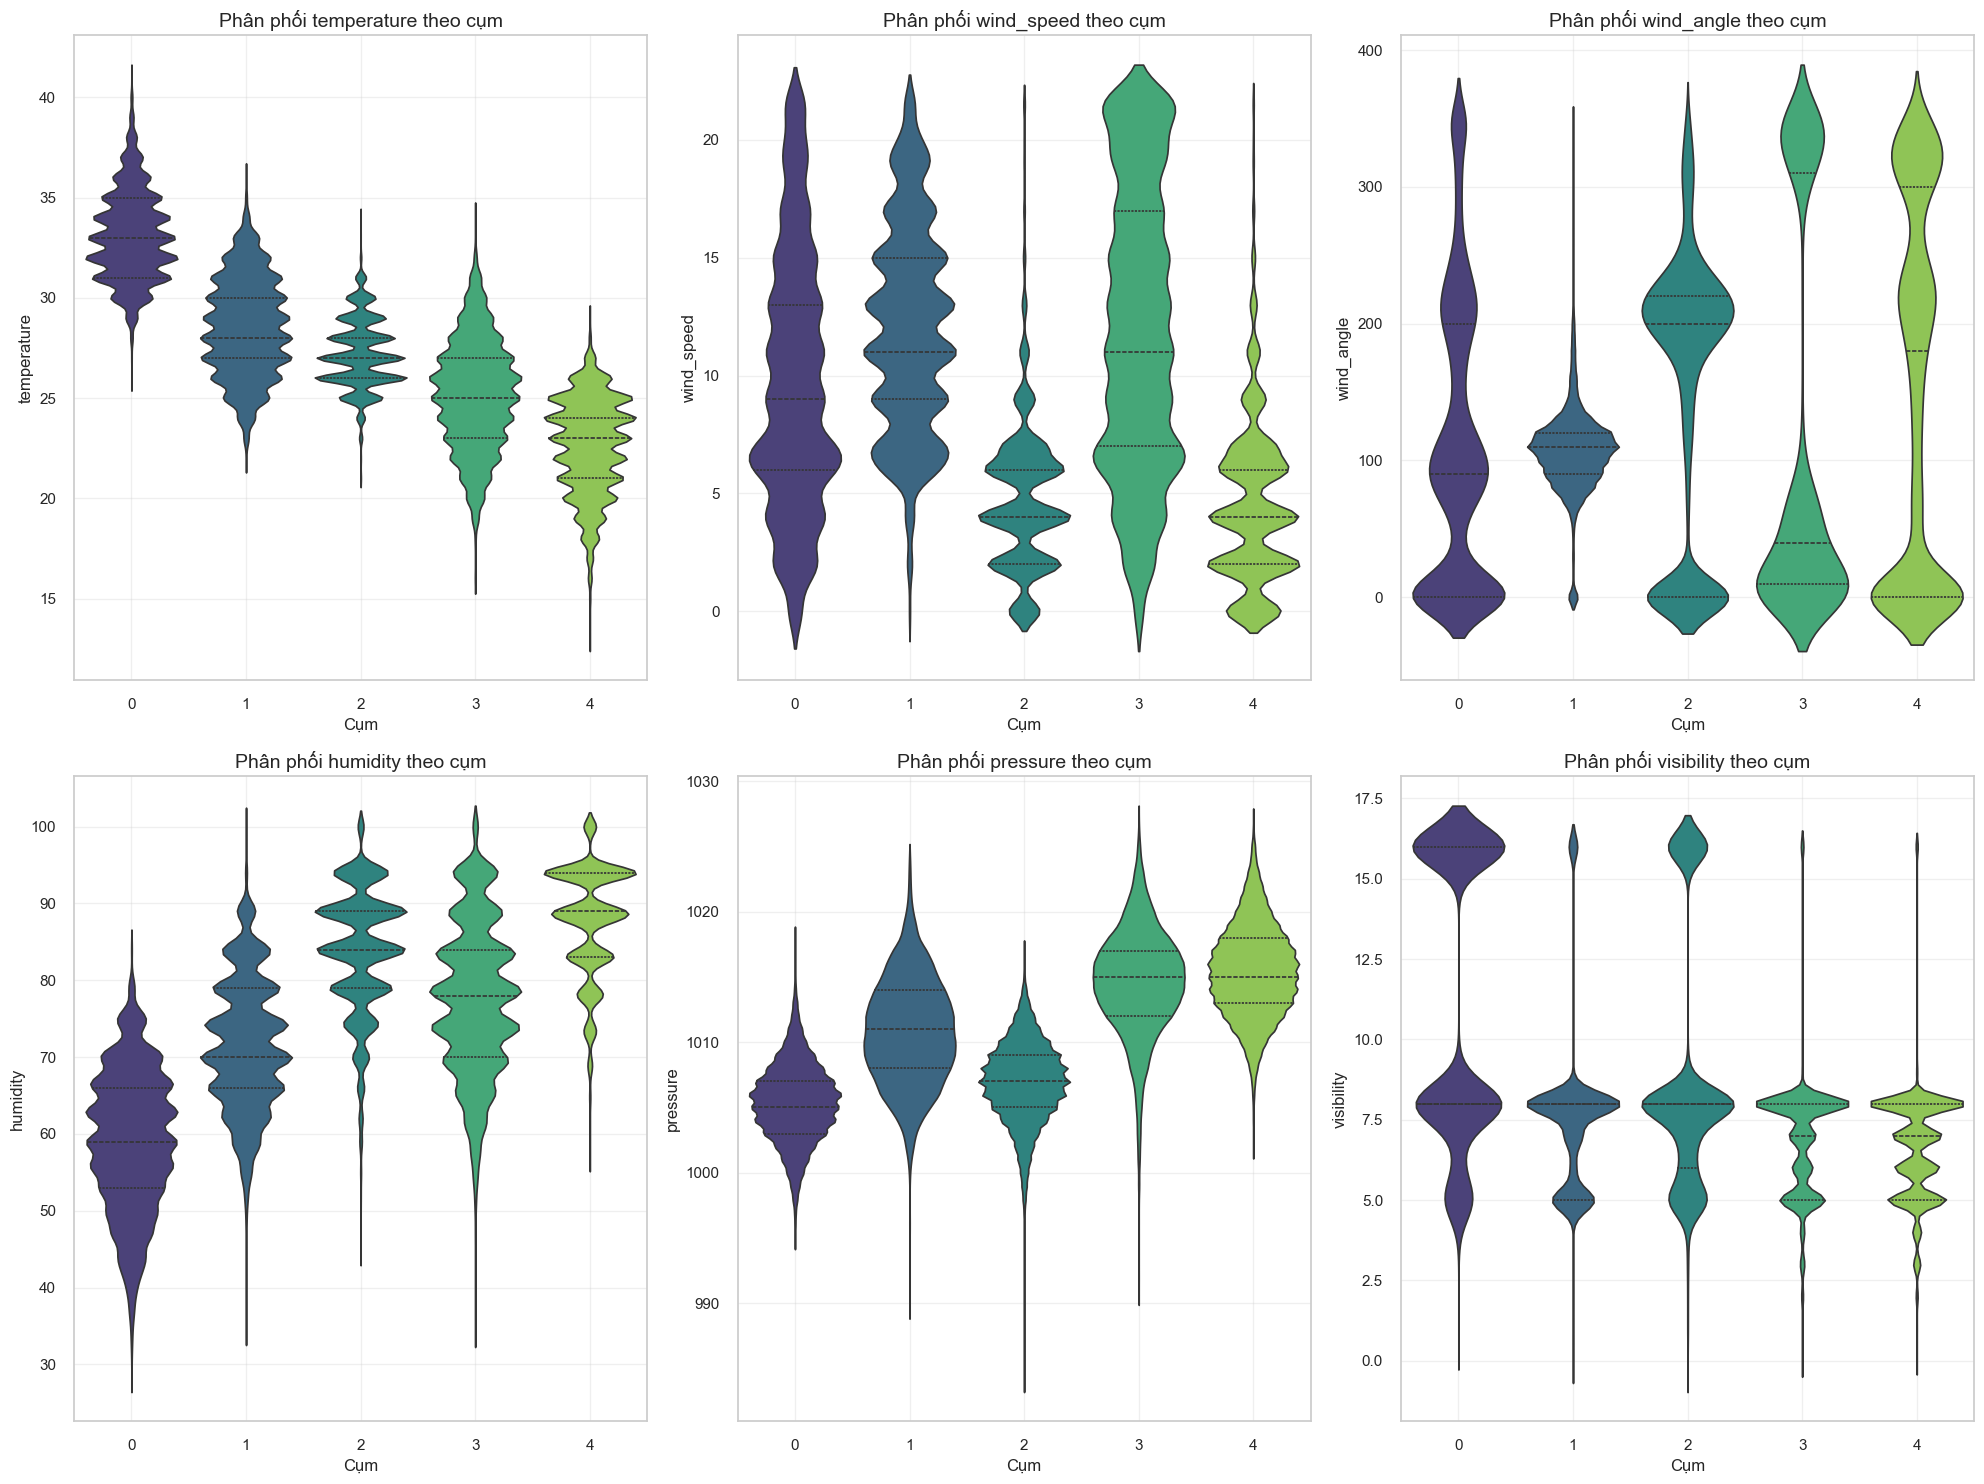

In [ ]:
plt.figure(figsize=(20, 15))
numeric_cols = [
    "temperature",
    "wind_speed",
    "wind_angle",
    "humidity",
    "pressure",
    "visibility",
]

for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i + 1)
    sns.violinplot(x="cluster", y=col, data=df, palette="viridis", inner="quartile")
    plt.title(f"Phân phối {col} theo cụm", fontsize=14)
    plt.xlabel("Cụm", fontsize=12)
    plt.ylabel(col, fontsize=12)
    plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Nhận xét:**
1. Temperature (Nhiệt độ):
    - Phân biệt rõ rệt giữa các cụm, với sự phân tách đều và liên tục từ cao xuống thấp qua các cụm.
2. Wind speed (Tốc độ gió):
    - Cụm 0,1,3 : Có tốc độ gió cao hơn, biến đổi mạnh từ (0-20 km/h)
    - Cụm 2,4: Tốc độ gió thấp hơn
3. Wind angle (Góc gió):
    - Có sự khác biệt rõ ràng giữa các cụm, đặc biệt về hình dạng phân phối và vị trí tập trung giá trị
    - Một số cụm thể hiện tính chất đa đỉnh (Cum 2, Cum 3, Cum 4)
    - Cum 1 là cụm có phân phối hẹp và tập trung nhất, có thể đại diện cho điều kiện gió ổn định hơn.
4. Humidity (Độ ẩm): Có sự khác biệt rõ rệt về độ ẩm giữa các cụm
    - Cụm 0 và ụm 1: độ ẩm trung bình, ổn định.
    - Cum 2 và Cum 3: độ ẩm cao, phân phối rộng.
    - Cum 4: độ ẩm rất cao, hẹp và ổn định.
5. Pressure (Áp suất):
    - Không có sự khác biệt rõ rệt giữa các cụm, áp suất trung bình dao động từ 1000-1015 hPa
6. Visibility (Tầm nhìn):
    - Tầm nhìn ở các cụm 3,4 thấp hơn so với các cụm 0,1
    - Điều này là hợp lý khi đối chiếu với biểu đồ phân phối  độ ẩm( Độ ẩm cao thường đi kèm với tầm nhìn thấp)
 

___

#### B. Mô hình Gaussian Mixture Model (GMM)

##### 1. Cơ sở lý thuyết:
 GMM là mô hình xác suất giả định rằng tất cả các điểm dữ liệu được sinh ra từ hỗn hợp của một số hữu hạn các phân phối Gaussian với các tham số khác nhau. Mỗi phân phối Gaussian đại diện cho một cụm. Thuật toán EM (Expectation-Maximization) được sử dụng để ước tính các tham số của mô hình.
##### 2. Siêu tham số chính:
- n_components: Số lượng phân phối Gaussian (cụm)
- covariance_type: Loại ma trận hiệp phương sai ('full', 'tied', 'diag', 'spherical')
- n_init: Số lần chạy thuật toán với các khởi tạo khác nhau

##### 3. Lựa chọn siêu tham số cho mô hình

In [45]:
# Các tham số cần tối ưu
n_components_range = range(2, 10)  # Số lượng cụm
covariance_types = ["full", "tied"]  # Loại ma trận hiệp phương sai
# covariance_types = ["full", "tied", "diag", "spherical"]

results = []

for n_components in n_components_range:
    for cov_type in covariance_types:
        try:
            # Áp dụng GMM
            gmm = GaussianMixture(
                n_components=n_components,
                covariance_type=cov_type,
                random_state=42,
                n_init=5,  # Giảm xuống tăng tốc độ thực thi
            )

            gmm.fit(df_pca)
            labels = gmm.predict(df_pca)
            # Tính các chỉ số đánh giá
            if len(np.unique(labels)) > 1:
                # sil_score = silhouette_score(df_pca, labels)
                # db_score = davies_bouldin_score(df_pca, labels)
                # ch_score = calinski_harabasz_score(df_pca, labels)
                bic_score = gmm.bic(df_pca)
                aic_score = gmm.aic(df_pca)
                results.append(
                    {
                        "n_components": n_components,
                        "covariance_type": cov_type,
                        # "silhouette": sil_score,
                        # "davies_bouldin": db_score,
                        # "calinski_harabasz": ch_score,
                        "bic": bic_score,
                        "aic": aic_score,
                    }
                )
                print(
                    f"n_components={n_components}, covariance_type={cov_type}: "
                    # f"silhouette={sil_score:.3f}, davies_bouldin={db_score:.3f}, "
                    # f"calinski_harabasz={ch_score:.1f},"
                    f"BIC={bic_score:.1f}, AIC={aic_score:.1f}"
                )
        except Exception as e:
            print(
                f"Lỗi với n_components={n_components}, covariance_type={cov_type}: {str(e)}"
            )

n_components=2, covariance_type=full: BIC=1902802.7, AIC=1902276.9
n_components=2, covariance_type=tied: BIC=1926004.5, AIC=1925679.4
n_components=3, covariance_type=full: BIC=1829001.6, AIC=1828208.0
n_components=3, covariance_type=tied: BIC=1915206.3, AIC=1914814.3
n_components=4, covariance_type=full: BIC=1782325.4, AIC=1781264.1
n_components=4, covariance_type=tied: BIC=1893503.2, AIC=1893044.3
n_components=5, covariance_type=full: BIC=1755744.6, AIC=1754415.6
n_components=5, covariance_type=tied: BIC=1872563.0, AIC=1872037.2
n_components=6, covariance_type=full: BIC=1719126.5, AIC=1717529.8
n_components=6, covariance_type=tied: BIC=1865561.8, AIC=1864969.0
n_components=7, covariance_type=full: BIC=1685726.5, AIC=1683862.1
n_components=7, covariance_type=tied: BIC=1825637.0, AIC=1824977.2
n_components=8, covariance_type=full: BIC=1669439.2, AIC=1667307.1
n_components=8, covariance_type=tied: BIC=1838883.1, AIC=1838156.5
n_components=9, covariance_type=full: BIC=1668034.3, AIC=16656

Trực quan hóa kết quả tìm siêu tham số

In [47]:
results_df = pd.DataFrame(results)

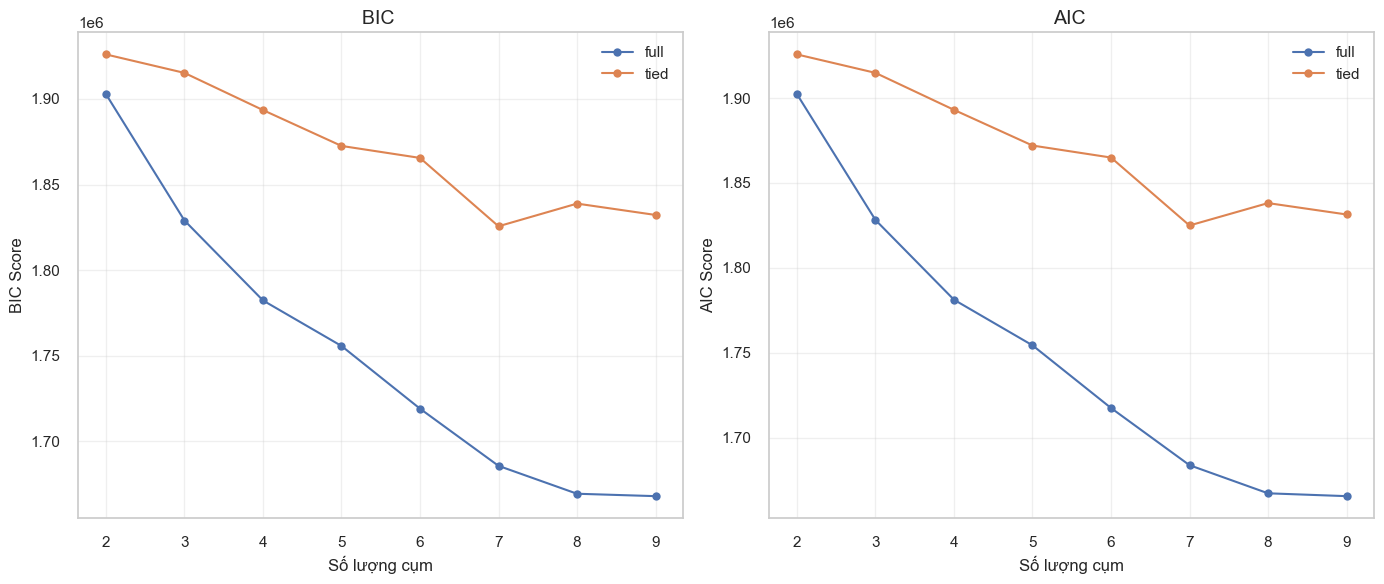

In [48]:
plt.figure(figsize=(14, 6))

# 1. BIC (Bayesian Information Criterion)
plt.subplot(1, 2, 1)
for cov_type in covariance_types:
    cov_data = results_df[results_df["covariance_type"] == cov_type]
    if not cov_data.empty:
        plt.plot(cov_data["n_components"], cov_data["bic"], marker="o", label=cov_type)
plt.title("BIC ", fontsize=14)
plt.xlabel("Số lượng cụm", fontsize=12)
plt.ylabel("BIC Score", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

# 2. AIC (Akaike Information Criterion)
plt.subplot(1, 2, 2)
for cov_type in covariance_types:
    cov_data = results_df[results_df["covariance_type"] == cov_type]
    if not cov_data.empty:
        plt.plot(cov_data["n_components"], cov_data["aic"], marker="o", label=cov_type)
plt.title("AIC ", fontsize=14)
plt.xlabel("Số lượng cụm", fontsize=12)
plt.ylabel("AIC Score", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Nhận xét:**
    - Ma trận "full" luôn cho kết quả tốt hơn ma trận "tied" ở cùng số lượng cụm
    - Đường cong "full" giảm mạnh từ 2 đến khoảng 7-8 cụm, sau đó tốc độ giảm chậm lại

- Mặc dù tăng lên 8-9 cụm vẫn có thể giảm BIC và AIC thêm chút ít, sự cải thiện không đáng kể so với việc tăng độ phức tạp của mô hình, gây nguy cơ overfitting trên tập dữ liệu thời tiết.
- Quyết định bộ tham số cho mô hình:
  - n_components = 7
  - covariance_type = "full"

##### 4. Huấn luyện GMM

In [49]:
optimal_n_components = 7
optimal_cov_type = "full"

gmm = GaussianMixture(
    n_components=optimal_n_components,
    covariance_type=optimal_cov_type,
    random_state=42,
    n_init=10,
)
gmm.fit(df_pca)
df["gmm_cluster"] = gmm.predict(df_pca)

In [ ]:
import pickle
import joblib
from pathlib import Path

Path("models").mkdir(exist_ok=True)
with open("models/gmm_model.pkl", "wb") as f:
    pickle.dump(gmm, f)

##### 5. Trực quan hóa kết quả GMM
*Phân phối số lượng mẫu trong từng cụm

* Biểu đồ phân phối số lượng mẫu trong từng cụm

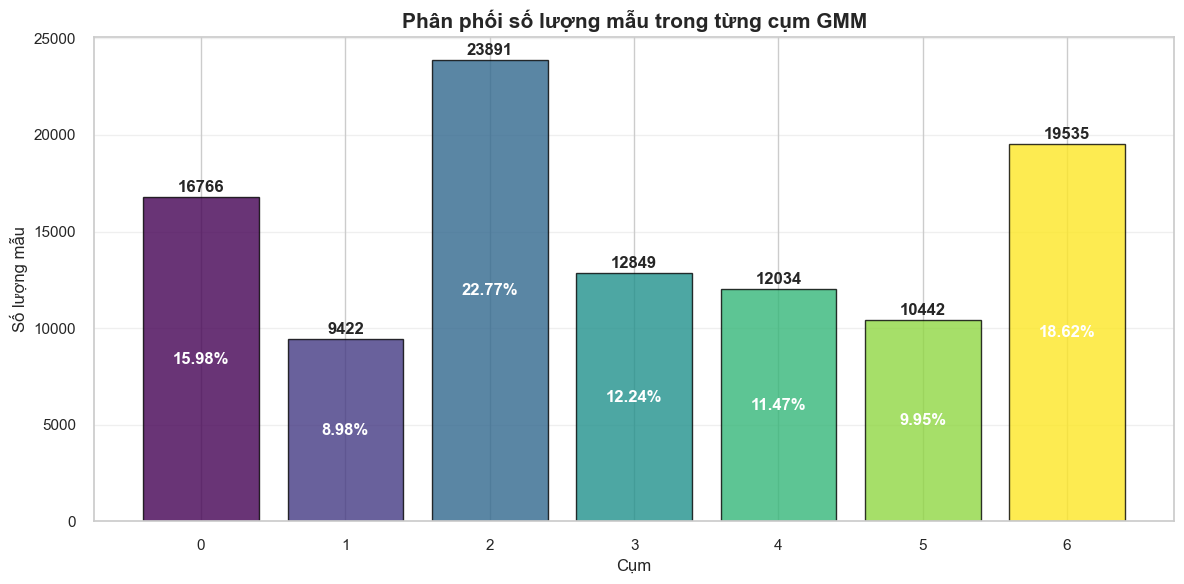

In [53]:
plt.figure(figsize=(12, 6))
gmm_cluster_counts = df["gmm_cluster"].value_counts().sort_index()
total_samples = gmm_cluster_counts.sum()
colors = plt.cm.viridis(np.linspace(0, 1, optimal_n_components))

bars = plt.bar(
    gmm_cluster_counts.index,
    gmm_cluster_counts.values,
    color=colors,
    alpha=0.8,
    edgecolor="black",
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 100,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )
    percent = 100 * height / total_samples
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height / 2,
        f"{percent:.2f}%",
        ha="center",
        va="center",
        fontweight="bold",
        color="white",
    )
plt.title(f"Phân phối số lượng mẫu trong từng cụm GMM", fontsize=15, fontweight="bold")
plt.xlabel("Cụm", fontsize=12)
plt.ylabel("Số lượng mẫu", fontsize=12)
plt.xticks(range(optimal_n_components))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Nhận xét:**

- Cụm 2 và 6 có số lượng mẫu lớn nhất, cho thấy đây là các kiểu thời tiết phổ biến hơn trong dữ liệu.
- Cụm 1 thấp nhất
- Tỷ lệ giữa cụm lớn nhất và nhỏ nhất khoảng 2.5 lần
- Phân cụm khá cân đối, không có cụm nào quá nhỏ (<5%) hay quá lớn (>30%)

* Biểu đồ phân cụm trên không gian PCA

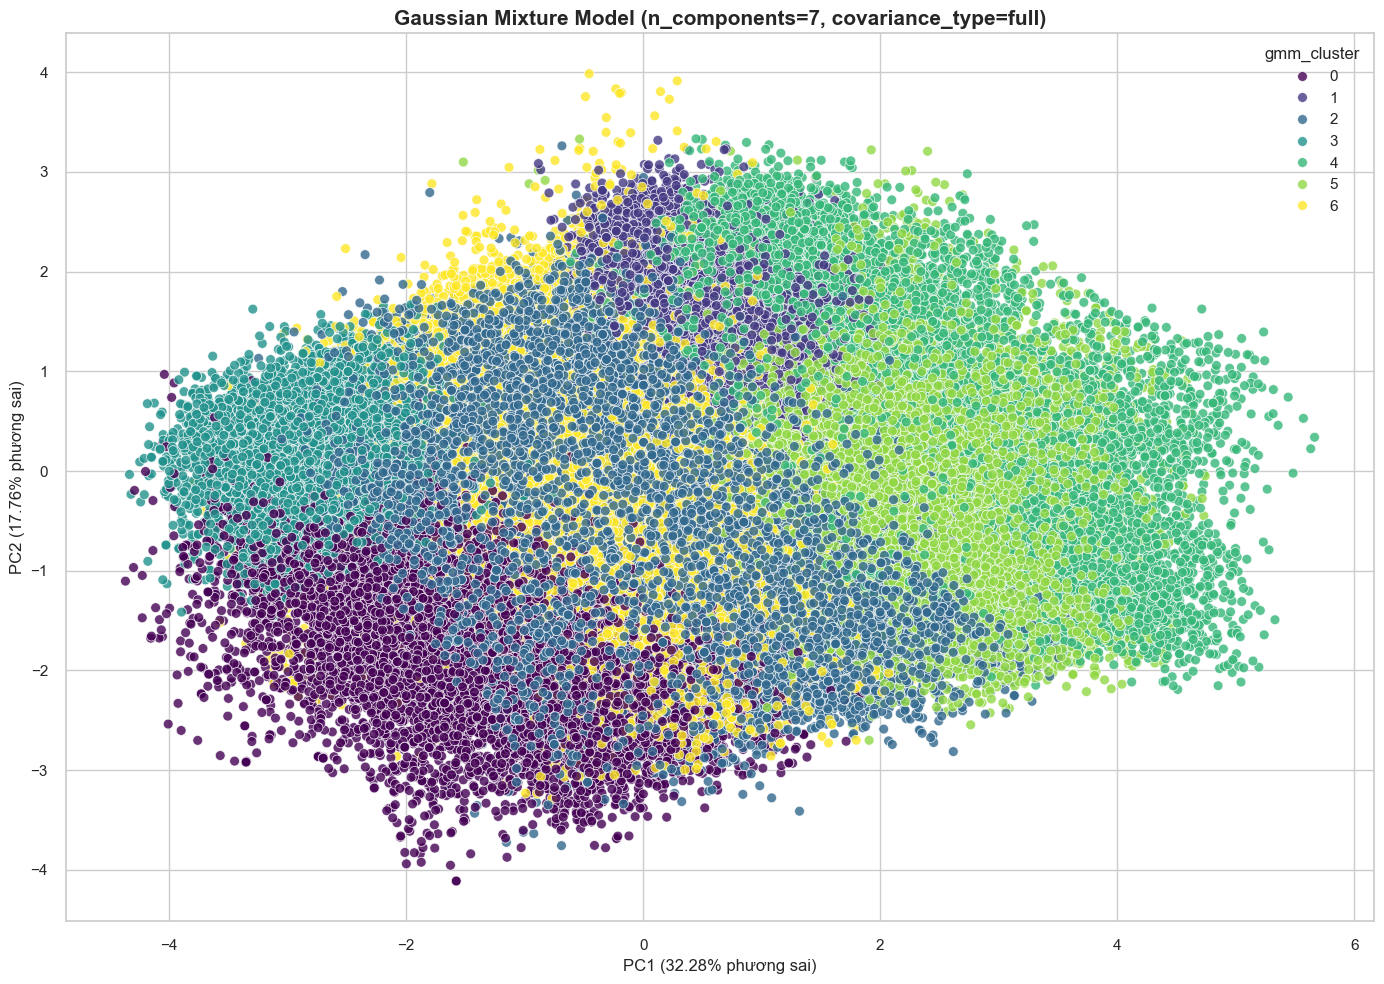

In [55]:
plt.figure(figsize=(14, 10))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="gmm_cluster",
    data=pd.concat([df_pca, df[["gmm_cluster"]]], axis=1),
    palette="viridis",
    alpha=0.8,
    s=50,
)
plt.title(
    f"Gaussian Mixture Model (n_components={optimal_n_components}, covariance_type={optimal_cov_type})",
    fontsize=15,
    fontweight="bold",
)
plt.xlabel(f"PC1 ({explained_variance[0]:.2%} phương sai)", fontsize=12)
plt.ylabel(f"PC2 ({explained_variance[1]:.2%} phương sai)", fontsize=12)
plt.tight_layout()
plt.show()

**Nhận xét:**
Các cụm được phân loại không quá rời rạc => Bản chất liên tục của hiện tượng thời tiết.

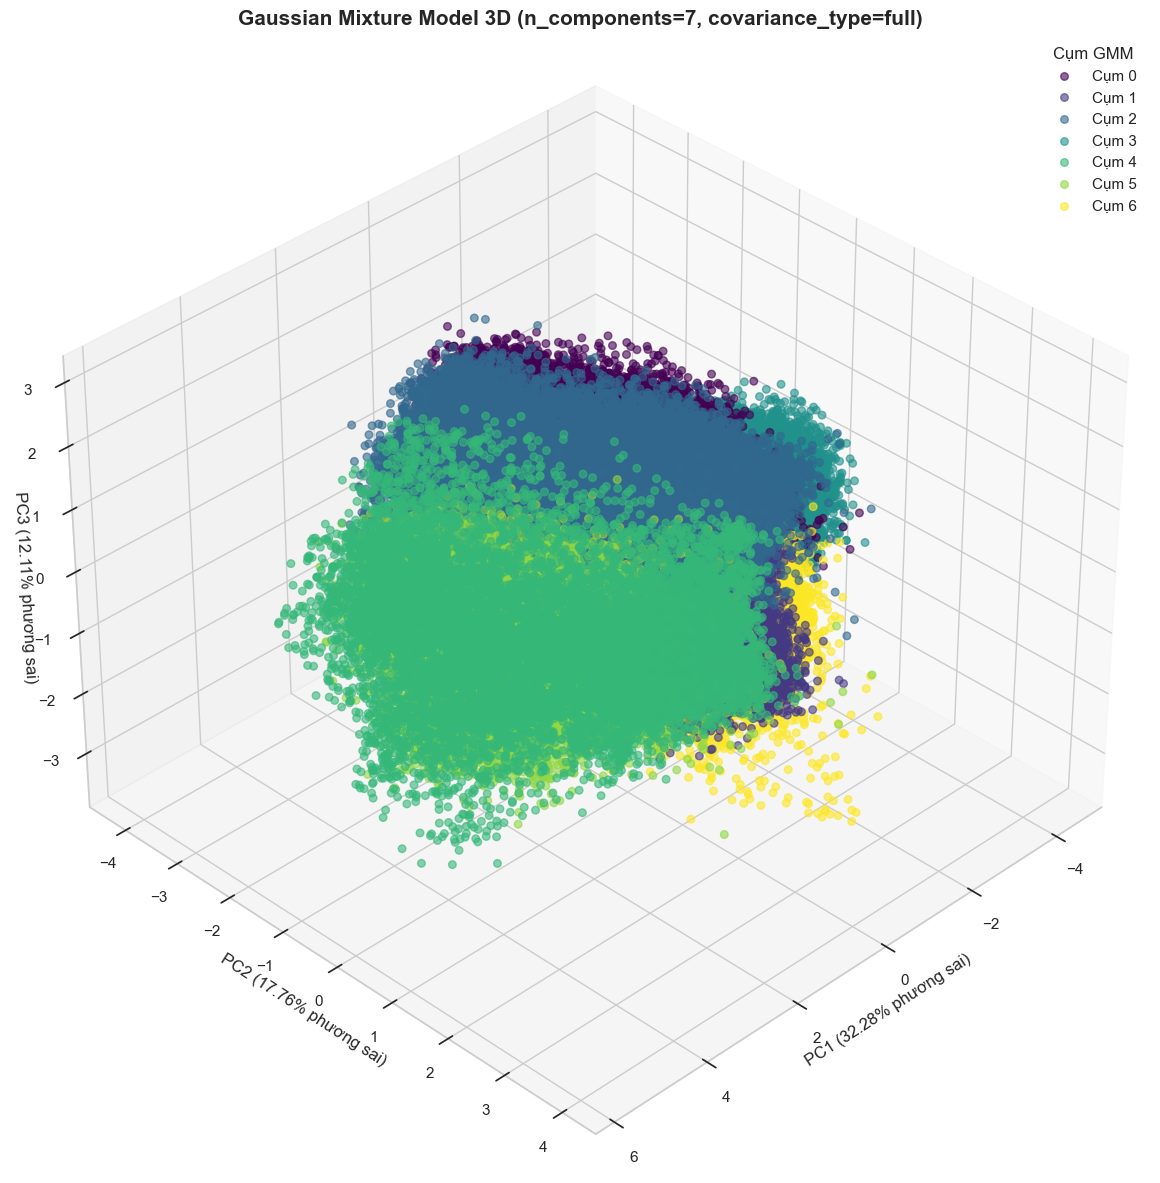

In [ ]:
# Biểu đồ 3D cho phân cụm GMM
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection="3d")

colors = plt.cm.viridis(np.linspace(0, 1, optimal_n_components))
df_plot = pd.concat([df_pca, df[["gmm_cluster"]]], axis=1)

for cluster_idx in range(optimal_n_components):
    cluster_data = df_plot[df_plot["gmm_cluster"] == cluster_idx]
    ax.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        cluster_data["PC3"],
        c=[colors[cluster_idx]],
        s=30,
        alpha=0.6,
        label=f"Cụm {cluster_idx}",
    )

ax.set_title(
    f"Gaussian Mixture Model 3D (n_components={optimal_n_components}, covariance_type={optimal_cov_type})",
    fontsize=15,
    fontweight="bold",
)
ax.set_xlabel(f"PC1 ({explained_variance[0]:.2%} phương sai)", fontsize=12)
ax.set_ylabel(f"PC2 ({explained_variance[1]:.2%} phương sai)", fontsize=12)
ax.set_zlabel(f"PC3 ({explained_variance[2]:.2%} phương sai)\n", fontsize=12)
ax.legend(title="Cụm GMM")
ax.view_init(elev=35, azim=45) 
plt.tight_layout()
plt.show()
# Thêm import
from matplotlib import animation


def rotate(angle):
    ax.view_init(azim=angle)
    return (fig,)


# Tạo animation
ani = animation.FuncAnimation(fig, rotate, frames=range(0, 360, 5), interval=150)
ani.save("gmm_3d_rotation.gif", writer="pillow", fps=5)

##### 6. Phân tích đặc điểm cụm và áp dụng domain knowledge

* Phân tích phân bố cụm theo tháng

<Figure size 1400x800 with 0 Axes>

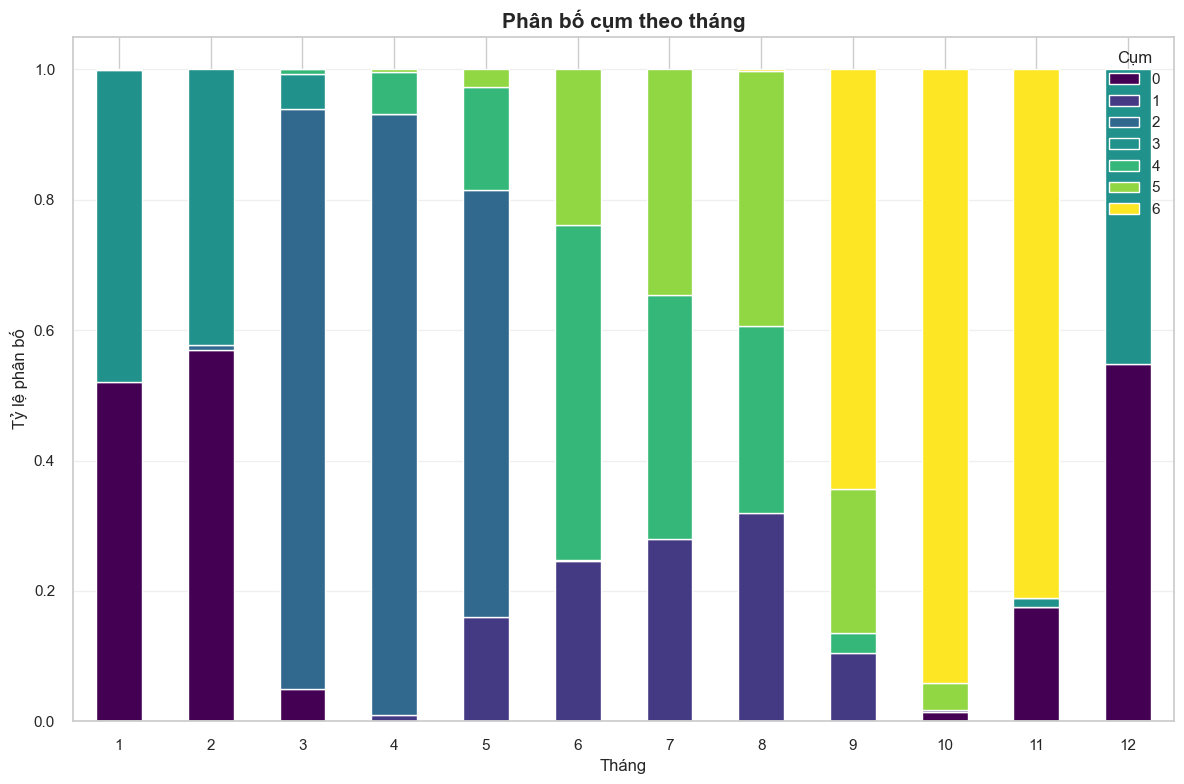

In [56]:
plt.figure(figsize=(14, 8))

monthly_cluster = pd.crosstab(df["month"], df["gmm_cluster"])

monthly_cluster_pct = monthly_cluster.div(monthly_cluster.sum(axis=1), axis=0)
monthly_cluster_pct.plot(kind="bar", stacked=True, colormap="viridis")

plt.title("Phân bố cụm theo tháng", fontsize=15, fontweight="bold")
plt.xlabel("Tháng", fontsize=12)
plt.ylabel("Tỷ lệ phân bố", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Cụm")
plt.tight_layout()
plt.show()

**Nhận xét:**
1. Mùa khô (tháng 1-7)
- Tháng 1-2: Chủ yếu là cụm 0 (màu xanh ngọc đậm) và cụm 1 (màu tím), với tỷ lệ tương đối cân bằng
- Tháng 3-5: Cụm 2 (màu xanh dương) chiếm ưu thế, với tỷ lệ giảm dần từ tháng 3 đến tháng 5
- Tháng 6-8: Cụm 3 (màu xanh ngọc nhạt) và cụm 4 (màu xanh lá nhạt) chiếm ưu thế

2. Mùa mưa (tháng 8-12)
- Tháng 9-11: Cụm 6 (màu vàng) là chủ đạo, đặc biệt tháng 10 gần như hoàn toàn thuộc cụm này
Tháng 12 và chuyển sang tháng 1:Quay trở lại với cụm 0 và cụm 1 chiếm ưu thế

=> Thể hiện chu kỳ của thời tiết trong năm

In [69]:
cluster_summary = (
    df.groupby("gmm_cluster")
    .agg(
        {
            "temperature": "mean",
            "humidity": "mean",
            "wind_speed": "mean",
            "pressure": "mean",
            "visibility_log": "mean",
            "wind_u": "mean",
            "wind_v": "mean",
            "hour_sin": "mean",
            "hour_cos": "mean",
            "month_sin": "mean",
            "month_cos": "mean",
        }
    )
    .round(2)
)
weather_distribution = pd.crosstab(
    df["gmm_cluster"], df["weather"], normalize="index"
).round(2)
cluster_summary = pd.concat([cluster_summary, weather_distribution], axis=1)
print("Bảng tổng hợp đặc điểm của từng cụm:")
display(cluster_summary)

Bảng tổng hợp đặc điểm của từng cụm:


,temperature,humidity,wind_speed,pressure,visibility_log,wind_u,wind_v,hour_sin,hour_cos,month_sin,month_cos,Clear,Cloudy,Foggy,Rainy,Stormy
gmm_cluster,,,,,,,,,,,,,,,,
0,24.18,76.43,10.88,1016.49,2.04,4.75,4.79,-0.26,-0.42,0.40,0.76,0.55,0.30,0.01,0.14,0.00
1,27.36,83.93,4.45,1005.58,2.07,-2.13,-2.43,0.17,0.62,-0.37,-0.71,0.89,0.04,0.00,0.06,0.01
2,27.22,78.17,8.35,1010.74,2.06,3.44,-0.05,-0.05,-0.02,0.82,-0.41,0.80,0.14,0.03,0.03,0.01
3,21.23,88.56,3.62,1016.63,2.01,-1.28,1.19,0.32,0.51,0.48,0.76,0.68,0.07,0.08,0.17,0.00
4,30.91,68.08,7.94,1005.68,2.83,2.09,-1.91,0.02,-0.04,-0.21,-0.80,0.94,0.06,0.00,0.00,0.00
5,32.29,62.52,10.14,1004.97,2.06,2.41,-0.25,-0.19,-0.52,-0.59,-0.58,0.73,0.21,0.00,0.03,0.03
6,26.41,83.49,7.69,1010.98,2.05,0.21,4.55,0.03,0.07,-0.78,0.49,0.59,0.16,0.01,0.22,0.02


* Biểu đồ phân bố các đặc trưng theo từng cụm

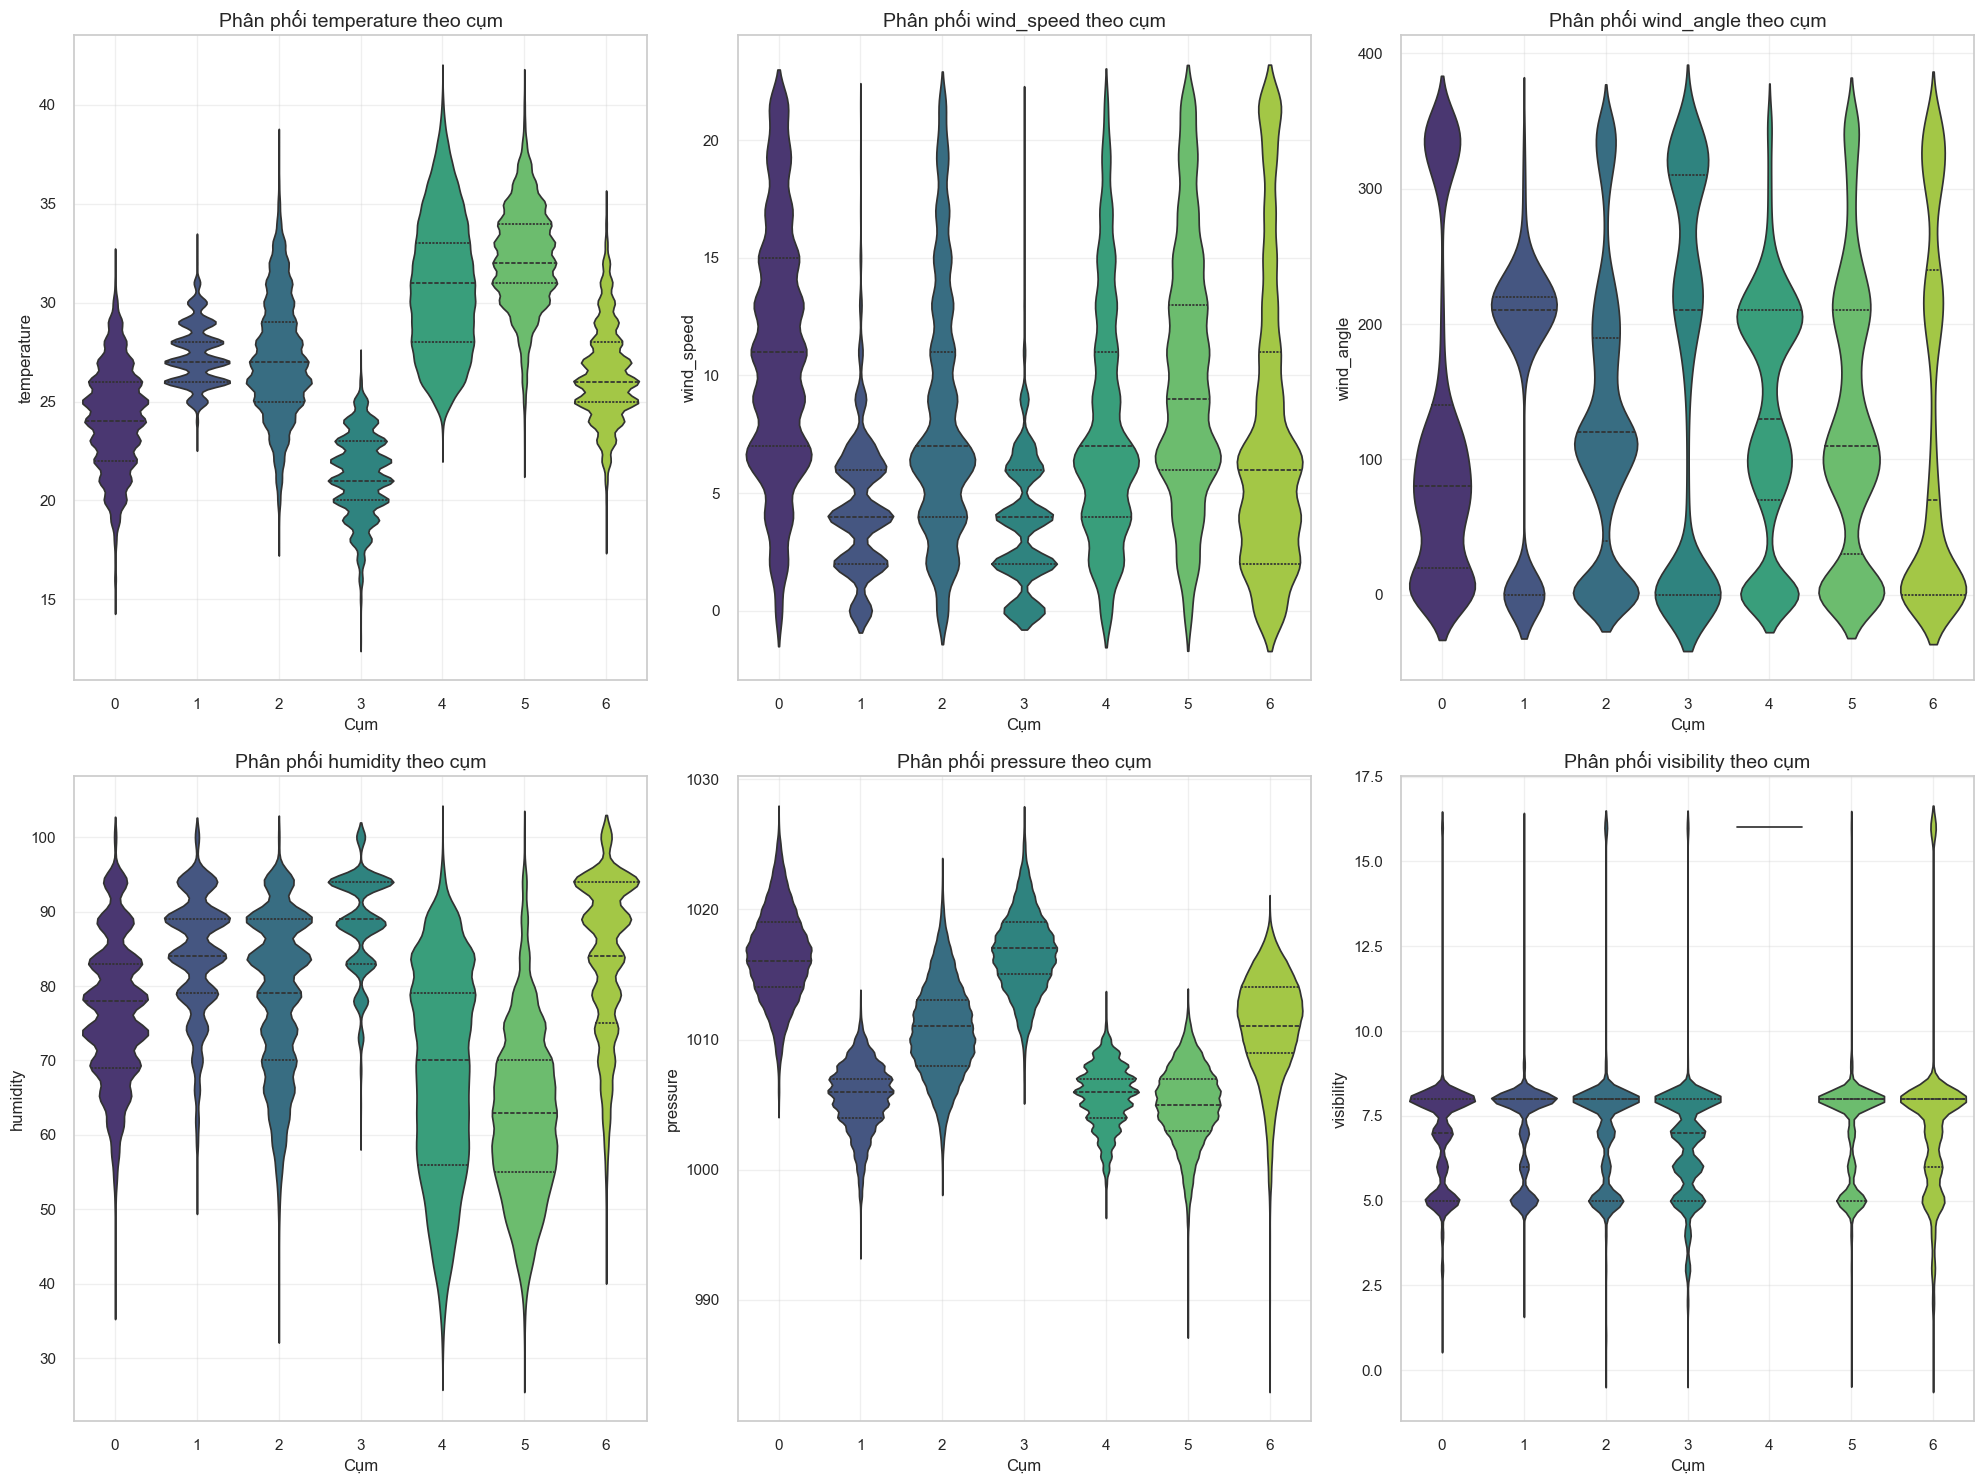

In [71]:
plt.figure(figsize=(20, 15))
numeric_cols = [
    "temperature",
    "wind_speed",
    "wind_angle",
    "humidity",
    "pressure",
    "visibility",
]

for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i + 1)
    sns.violinplot(x="gmm_cluster", y=col, data=df, palette="viridis", inner="quartile")
    plt.title(f"Phân phối {col} theo cụm", fontsize=14)
    plt.xlabel("Cụm", fontsize=12)
    plt.ylabel(col, fontsize=12)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

***Nhận xét:**

#### C. Kết luận và đánh giá tổng thể 2 mô hình phân cụm

In [72]:
kmeans_labels = df["cluster"]
gmm_labels = df["gmm_cluster"]

kmeans_silhouette = silhouette_score(df_pca, kmeans_labels)
gmm_silhouette = silhouette_score(df_pca, gmm_labels)

kmeans_db = davies_bouldin_score(df_pca, kmeans_labels)
gmm_db = davies_bouldin_score(df_pca, gmm_labels)
comparison_df = pd.DataFrame(
    {
        "K-means": [
            int(optimal_k),
            round(kmeans_silhouette, 3),
            round(kmeans_db, 3),
        ],
        "GMM": [
            int(optimal_n_components),
            round(gmm_silhouette, 3),
            round(gmm_db, 3),
        ],
    },
    index=[
        "Số cụm",
        "Silhouette Score ",
        "Davies-Bouldin Index ",
    ],
)
print("\nChỉ số đánh giá giữa K-means và GMM")
display(comparison_df)


Chỉ số đánh giá giữa K-means và GMM


,K-means,GMM
Số cụm,5.000,7.000
Silhouette Score,0.196,0.104
Davies-Bouldin Index,1.572,1.763


- Silhouette Score: thấp với cả 2 mô hình 
- Davies-Bouldin Index (giá trị thấp hơn là tốt hơn)
- Cả hai chỉ số (Silhouette và Davies-Bouldin) đều cho thấy K-means tạo ra cụm có chất lượng tốt hơn